# Exploring a nested parameter sweep

In this notebook, we explore a monolayer WSe<sub>2</sub> sample subject to a nested parameter sweep: we sweep both bottom gate voltage and excitation power. We probe the sample with a laser spot and measure the photoluminescence.

In this measurement with the AttoCube, we declared the bottom voltage (on channel A) to be the slow sweep and the excitation power (controlled by the filter wheel) to be the fast sweep. If we have L bottom gate voltages and M excitation powers used, we expect $L\times M = N$ sweep points, which can be arranged into a matrix with coordinates $(l,m)$:

$$
\begin{pmatrix}
(l_0, m_0) & (l_0, m_0) & \dots & (l_0, m_M)\\
(l_1, m_0) & (l_1, m_1) & \dots & (l_1, m_M)\\
\vdots & \ddots & \ddots & \vdots \\
(l_L, m_0) & (l_L, m_1) & \dots & (l_L, m_M)
\end{pmatrix}
$$

This notebook will cover
1. The loading of the dataset
2. Navigating the relevant attributes of the dataset.
3. Manipulating and slicing the nested parameter sweep


## References
- Li, Z. et al. Emerging photoluminescence from the dark-exciton phonon replica in monolayer WSe2. Nat Commun 10, 2469 (2019).
- He, M. et al. Valley phonons and exciton complexes in a monolayer semiconductor. Nat Commun 11, 618 (2020).
- Li, Z. et al. Revealing the biexciton and trion-exciton complexes in BN encapsulated WSe2. Nat Commun 9, 3719 (2018).
- Ye, Z. et al. Efficient generation of neutral and charged biexcitons in encapsulated WSe2 monolayers. Nat Commun 9, 3718 (2018).
- Barbone, M. et al. Charge-tuneable biexciton complexes in monolayer WSe2. Nat Commun 9, 3721 (2018).

In [1]:
import leman as tmdc
from leman.loaders import ACSpectralSweep, DeviceGeometry, StackLayer
from leman.plotting import plot_spectral_map, plot_spectral_series

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import seaborn as sns

We load our device geometry and our dataset. In this dataset of the nested sweep, we have to declare our fast and slow sweep axes. Doing so informs the loaders which parameters to check. Behind the scenes, the loader checks if the parameter is indeed varying by analysing how the parameter value changes across the scans. It does this for both the fast and sweep axes and performs a final check that the $L\times M=N$ condition holds.

In [2]:
folder_path = Path('./data/voltage-power-sweep')

geom = DeviceGeometry(
    d_hbn_top = 30,
    d_hbn_bottom = 26,
    tmdc_stack = [StackLayer("WSe2")],
    label = "hBN/WSe2(Flux)/hBN"
)

scan = ACSpectralSweep(
    path = sorted(folder_path.glob("PL_Vbot_power_sweep*.csv"))[0],
    spectra_type = "PL",
    fast_sweep = "bottom_voltage",
    slow_sweep = "power",
    gates = {"bottom" : "V_A", "channel" : "V_B"},
    cosmic_rays = {},
    bg_region_eV = [1.55,1.6],                         #
    apply_jacobian = True,                             #
    curated_scales = {"v_bot" : -1}                    # In our experiment, we swapped the TMDC and back gate leads by accident.
)

C:\Users\Brandon\AppData\Local\Temp\ipykernel_21344\2156349701.py:10: UserWarning: curated_scales rescaled 'v_bot' 1 -> -1, unit still 'V'. Pass curated_units={'v_bot': ...} to state what the numbers now are — the unit reaches every axis label, __repr__ line and legend entry, so it is a misread otherwise.
  scan = ACSpectralSweep(
C:\Users\Brandon\Documents\02_Areas\LANES-TMDC-Optics-Tools\src\leman\loaders.py:4333: UserWarning: 14 flagged pixel(s) kept their raw values because every pixel in their median_window=7 window was flagged too: pixel 572 (sweep 57), pixel 572 (sweep 58), pixel 573 (sweep 58), .... A run of flagged pixels that wide has no unflagged neighbour left to take a median from, so part of the spike survives the repair. Pass a larger median_window to reach it.
  self.spectra_cr, self.cosmic_ray_mask = processing.remove_cosmic_rays(


We first check a number of attributes of this scan:

In [3]:
print(f"The scan has the following parameters which change from scan to scan: {list(scan.varying_parameters().keys())}")
print(f"The device is swept with the following gate mode: {scan.gate_mode}. Is it dual-gated? {scan.is_dual_gated}")
print(f"Is the scan nested? {scan.is_nested}")
print(f"The nested scan has the following shape: {scan.nesting}")
print(f"The fast axis has the following values: {scan.nesting.fast_axis} in volts")
print(f"The slow axis has the following values: {scan.nesting.slow_axis} in micro watts")

The scan has the following parameters which change from scan to scan: ['I_A', 'V_A', 'Excitation Power', 'I_B', 'V_B', 'Fianium_Select_A4']
The device is swept with the following gate mode: bottom-gate only. Is it dual-gated? False
Is the scan nested? True
The nested scan has the following shape: bottom_voltage (11, fast) × power (7, slow) = 77
The fast axis has the following values: [ 4.999810e+00  3.999851e+00  2.999950e+00  1.999988e+00  9.999885e-01
 -2.763980e-06 -9.999909e-01 -1.999991e+00 -3.000076e+00 -4.000227e+00
 -5.000054e+00] in volts
The slow axis has the following values: [ 0.19790381  0.54492944  1.4302449   3.07315902  5.95586647 11.42820464
 23.05606144] in micro watts


Let's look at one excitation power, $23\;\mathrm{\mu W}$. We can get the spectrum of the bottom gate voltage sweep at this excitation power by calling `get_spectrum_at`. We pass in the value that we want, `fast=23`, and the function takes the nearest value to the one we supplied.

In [4]:
scan.get_spectrum_at(slow = 23.0)

array([[ 2821.68919648,  3107.21437461,  3705.50393015, ...,
         1335.69359309,   223.75056549,  -495.1697297 ],
       [ 1095.16036793,   982.33745258,  1049.44763499, ...,
        -1187.07213948, -3095.33558698, -2486.48088864],
       [  -99.67039864,   -79.73631891,   651.01787209, ...,
        -2514.12503107, -2829.18073018, -4078.70719119],
       ...,
       [-4072.22648486, -3676.90195335, -3914.51537432, ...,
        -5328.68159342, -6316.81846303, -7118.28399604],
       [-3880.6450839 , -3771.11496647, -3532.52069794, ...,
        -5517.66687075, -6600.75927394, -7211.54664849],
       [-3593.96672279, -3674.87107751, -3912.35325665, ...,
        -5801.74891977, -6694.13790129, -7399.95865104]], shape=(1340, 11))

If we tried `fast=20`, we would still get the same array because the next value is at 11 uW, but we would get a warning telling us that our selected value is a little far away from the true value in the dataset:

In [5]:
scan.get_spectrum_at(slow = 20.0)[0:]

C:\Users\Brandon\Documents\02_Areas\LANES-TMDC-Optics-Tools\src\leman\loaders.py:4825: UserWarning: Looking up 20 µW on Power (axis='slow') found no point there; using index 6 at 23.0561 µW, which is 3.05606 µW away. The axis spans 0.197904 to 23.0561 µW in 7 points.
  selector = self._sweep_selector(


array([[ 2821.68919648,  3107.21437461,  3705.50393015, ...,
         1335.69359309,   223.75056549,  -495.1697297 ],
       [ 1095.16036793,   982.33745258,  1049.44763499, ...,
        -1187.07213948, -3095.33558698, -2486.48088864],
       [  -99.67039864,   -79.73631891,   651.01787209, ...,
        -2514.12503107, -2829.18073018, -4078.70719119],
       ...,
       [-4072.22648486, -3676.90195335, -3914.51537432, ...,
        -5328.68159342, -6316.81846303, -7118.28399604],
       [-3880.6450839 , -3771.11496647, -3532.52069794, ...,
        -5517.66687075, -6600.75927394, -7211.54664849],
       [-3593.96672279, -3674.87107751, -3912.35325665, ...,
        -5801.74891977, -6694.13790129, -7399.95865104]], shape=(1340, 11))

The shape is correct: we have 1340 pixels (wavelength values at which the intensity is measured) over 11 bottom gate voltage values. We can check if the two arrays are indeed the same:

In [6]:
print(f"The two arrays are the same? {np.allclose(scan.get_spectrum_at(slow = 20.0), scan.get_spectrum_at(slow=23.0))}")

The two arrays are the same? True


Now we plot the spectral map for this excitation power. The scan looks quite coarse, but that's because we swept at 1 V intervals.

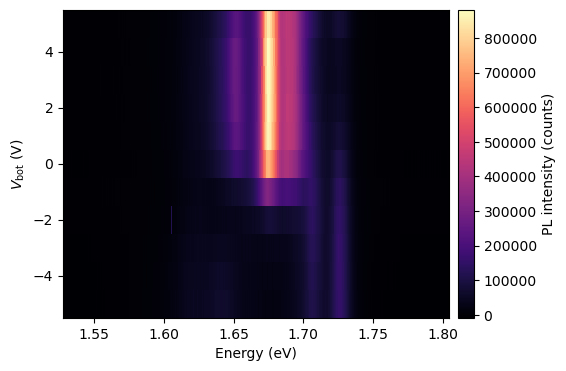

In [7]:
fig, ax, mesh = plot_spectral_map(scan, slow = 23.0)

We could plot something similar but with each spectrum overlaid on top of each other as a line plot. It's the same data, but it could be easier to visualise how the spectral peaks change:

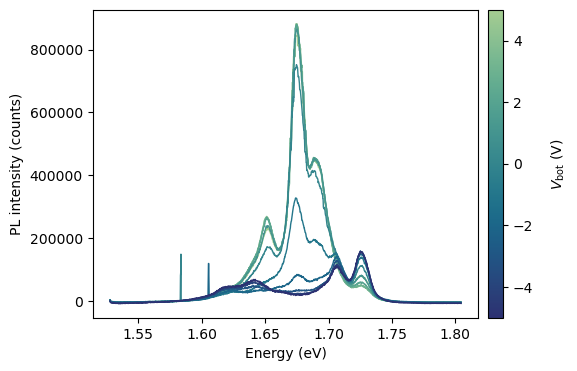

In [8]:
fig, ax, *_ = plot_spectral_series(scan, slow = 23.0, cmap = sns.color_palette("crest_r", as_cmap=True))

Now we look at one particular gate voltage and visualise how the peaks change with increasing excitation power. For illustration purposes, let's plot the power dependence of the spectra at $V_G = 0$ and $V_G = 0$.

Text(0.5, 1.0, '$V_G =5\\;V$')

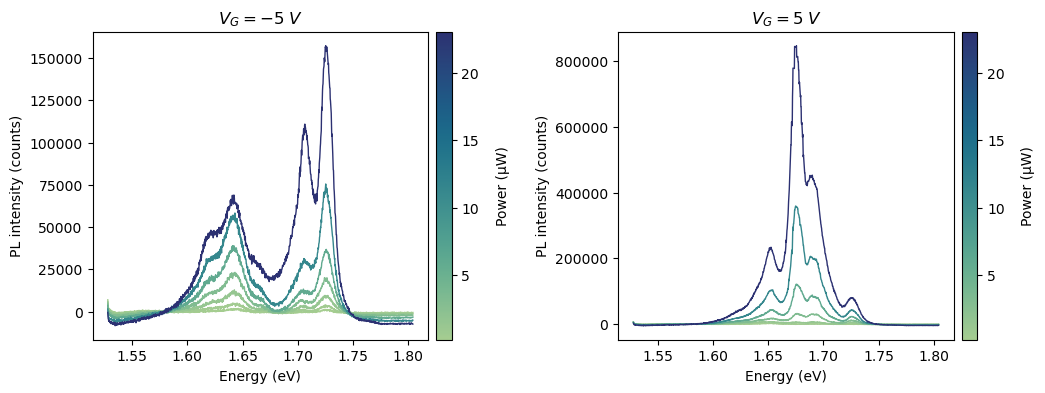

In [9]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12,4), gridspec_kw = {'wspace': 0.3})

fig, ax1, *_ = plot_spectral_series(scan, fast = -5, ax=ax1, cmap = sns.color_palette("crest", as_cmap = True))
fig, ax2, *_ = plot_spectral_series(scan, fast = 5.0, ax=ax2, cmap = sns.color_palette("crest", as_cmap = True))

ax1.set_title(r"$V_G =-5\;V$")
ax2.set_title(r"$V_G =5\;V$")